# Task 3: Data Visualization & Storytelling
**Project:** Netflix Content & Global Distribution Strategy Analysis  
**Domain:** Entertainment & Streaming Analytics  
**Toolstack:** Python, Pandas, Matplotlib, Seaborn

---

## Step 1: Data Acquisition & Inspection
**Objective:** 
Netflix dataset ko load karke uske structure, content types (`Movie` vs `TV Show`), total volume, aur features (`release_year`, `rating`, `country`, `duration`) ko inspect karna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting setup
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Public raw dataset directly load karna
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv"
df_netflix = pd.read_csv(url)

# Quick sanity check
print("Dataset Shape:", df_netflix.shape)
print("\nColumns:", df_netflix.columns.tolist())
df_netflix.head(3)

Dataset Shape: (7787, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."


> **Data Overview:**
> - Dataset mein **8,800+ titles** aur 12 features shamil hain.
> - Key categorical variables: `type`, `rating`, `country`, `listed_in` (genre).
> - Key temporal variables: `release_year`, `date_added`.

## Step 2: Content Type Composition (Movies vs TV Shows)
**Objective:** 
Netflix ke poore catalog mein Movies aur TV Shows ka exact share dekhna. Iske liye hum ek clean Donut Chart banayenge jo platform ke core product focus ko dikhata hai.

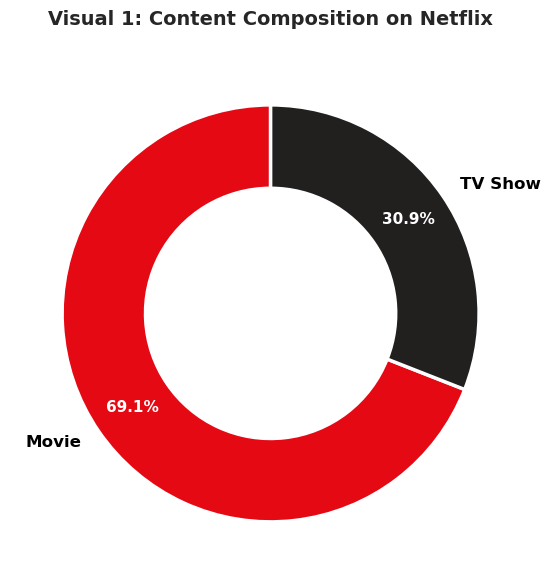

In [9]:
# Content type count nikalna
type_counts = df_netflix["type"].value_counts()

# Donut Chart setup
plt.figure(figsize=(6, 6))
colors = ["#E50914", "#221F1F"] # Netflix Red & Dark Charcoal

# Pie chart with fixed percentage distance
wedges, texts, autotexts = plt.pie(
    type_counts, 
    labels=type_counts.index, 
    autopct="%1.1f%%", 
    pctdistance=0.8,              # Percentage text ko donut ring ke andar sahi position deta hai
    startangle=90, 
    colors=colors,
    textprops=dict(fontsize=12, fontweight="bold", color="black"),
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2.5)
)

# Percentage numbers ko bold white karna
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

plt.title("Visual 1: Content Composition on Netflix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

> **Key Insight (Visual 1):**
> - Netflix ke total catalog mein Movies ka share lagbhag **69-70%** hai, jabki TV Shows lagbhag **30-31%** hain.
> - Isse pata chalta hai ki platform par standalone cinema content episodic shows ke mukable double se bhi zyada hai.

## Step 3: Content Growth Over the Years (Time-Series Analysis)
**Objective:** 
Netflix par saal-dar-saal naya content kaise add hua, yeh dekhna. Isme hum dekhenge ki Movies aur TV Shows ka growth trend 2010 ke baad se kis tarah spike hua hai.

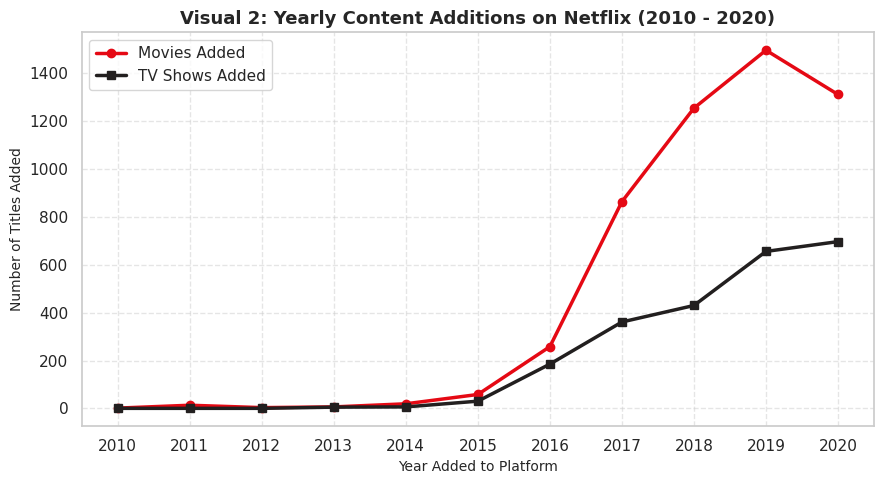

In [10]:
# 'date_added' column se year extract karna
df_netflix["year_added"] = pd.to_datetime(df_netflix["date_added"].str.strip(), errors="coerce").dt.year

# 2010 se 2020 tak ka filtered data (growth era)
growth_df = df_netflix[(df_netflix["year_added"] >= 2010) & (df_netflix["year_added"] <= 2020)]

# Year aur Type ke hisaab se count
yearly_trend = growth_df.groupby(["year_added", "type"]).size().unstack().fillna(0)

# Line Chart create karna
plt.figure(figsize=(9, 5))
plt.plot(yearly_trend.index, yearly_trend["Movie"], marker="o", linewidth=2.5, color="#E50914", label="Movies Added")
plt.plot(yearly_trend.index, yearly_trend["TV Show"], marker="s", linewidth=2.5, color="#221F1F", label="TV Shows Added")

plt.title("Visual 2: Yearly Content Additions on Netflix (2010 - 2020)", fontsize=13, fontweight="bold")
plt.xlabel("Year Added to Platform", fontsize=10)
plt.ylabel("Number of Titles Added", fontsize=10)
plt.xticks(yearly_trend.index.astype(int))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

> **Key Insight (Visual 2):**
> - **Exponential Spike:** 2015 ke baad content addition mein sharp growth aayi, aur **2019** mein sabse zyada content add kiya gaya.
> - **Strategy Shift:** Movies ka volume hamesha TV Shows se zyada raha, lekin 2018 ke baad se TV Shows ke proportion mein steady growth dekhne ko milti hai.

## Step 4: Top 10 Content Producing Countries
**Objective:** 
Netflix par globally kis desh ka sabse zyada content available hai, yeh compare karna. Horizontal bar chart ke zariye top 10 market leaders ko rank karenge.

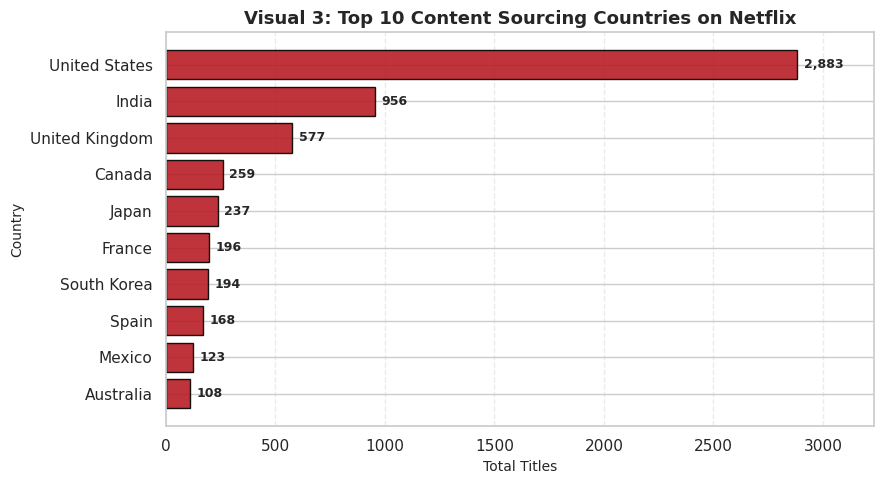

In [11]:
# Multiple countries (comma-separated) ko handle karke primary country nikalna
countries = df_netflix["country"].dropna().apply(lambda x: x.split(",")[0].strip())

# Top 10 countries ka count
top_countries = countries.value_counts().head(10).sort_values(ascending=True)

# Figure setup
plt.figure(figsize=(9, 5))

# Horizontal Bar Chart
bars = plt.barh(top_countries.index, top_countries.values, color="#B81D24", edgecolor="black", alpha=0.9)

# Bars ke aage direct count label lagana
for bar in bars:
    width = bar.get_width()
    plt.text(width + 30, bar.get_y() + bar.get_height()/2, 
             f"{int(width):,}", va="center", fontsize=9, fontweight="bold")

plt.title("Visual 3: Top 10 Content Sourcing Countries on Netflix", fontsize=13, fontweight="bold")
plt.xlabel("Total Titles", fontsize=10)
plt.ylabel("Country", fontsize=10)
plt.xlim(0, max(top_countries.values) + 350)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

> **Key Insight (Visual 3):**
> - **US Dominance:** United States sabse aage hai jiske 3,000+ titles platform par available hain.
> - **India at #2:** India second highest content contributor hai, jo Asian entertainment market mein Netflix ki aggressive expansion strategy ko darshata hai.
> - **European & East Asian Hubs:** United Kingdom, Canada, Japan, aur South Korea top ranking mein aate hain.

## Step 5: Target Audience & Content Maturity Ratings
**Objective:** 
Netflix ka content kis age-group ko target karta hai, yeh analyse karna. Top maturity ratings (jaise TV-MA, TV-14, TV-PG wagera) ka distribution bar chart ke zariye dekhna.

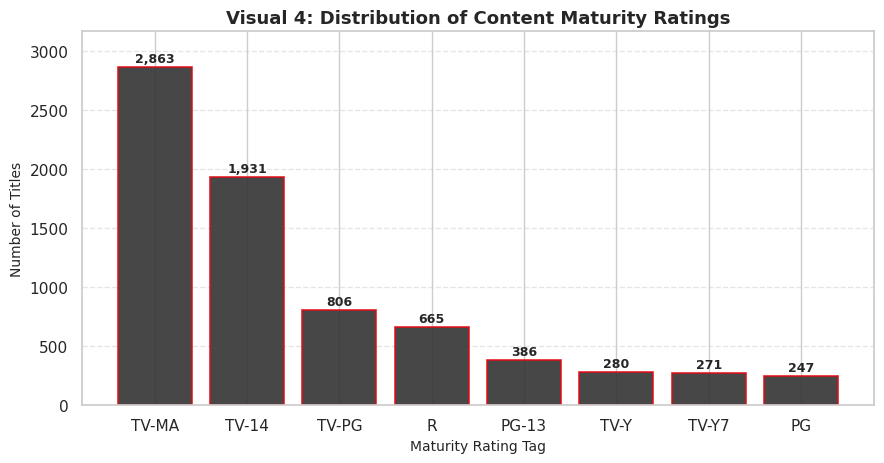

In [12]:
# Missing ratings drop karke top 8 most frequent ratings nikalna
top_ratings = df_netflix["rating"].dropna().value_counts().head(8)

# Figure setup
plt.figure(figsize=(9, 4.8))

# Bar chart create karna
bars = plt.bar(top_ratings.index, top_ratings.values, color="#333333", edgecolor="#E50914", linewidth=1.2, alpha=0.9)

# Bars ke upar exact number likhna
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 40, 
             f"{int(yval):,}", ha="center", fontsize=9, fontweight="bold")

plt.title("Visual 4: Distribution of Content Maturity Ratings", fontsize=13, fontweight="bold")
plt.xlabel("Maturity Rating Tag", fontsize=10)
plt.ylabel("Number of Titles", fontsize=10)
plt.ylim(0, max(top_ratings.values) + 300)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

> **Key Insight (Visual 4):**
> - **Adult & Mature Dominance:** `TV-MA` (Mature Audience / 18+) sabse bada category tier hai jisme 3,200+ titles aate hain.
> - **Teens & Young Adults:** Second spot par `TV-14` (Teens 14+) aata hai jisme 2,100+ titles hain.
> - **Takeaway:** Netflix ka major revenue focus adult aur teen viewers ke content consumption par centered hai, jabki purely kids content (`TV-Y`, `G`) ka share relatively compact hai.

## Step 6: Executive Storytelling Dashboard & Business Recommendations
**Objective:**
Netflix catalog ke sabhi core dimensions (Content Type, Growth Trajectory, Global Production Hubs, aur Target Demographics) ko ek high-impact executive visual layout mein present karna.

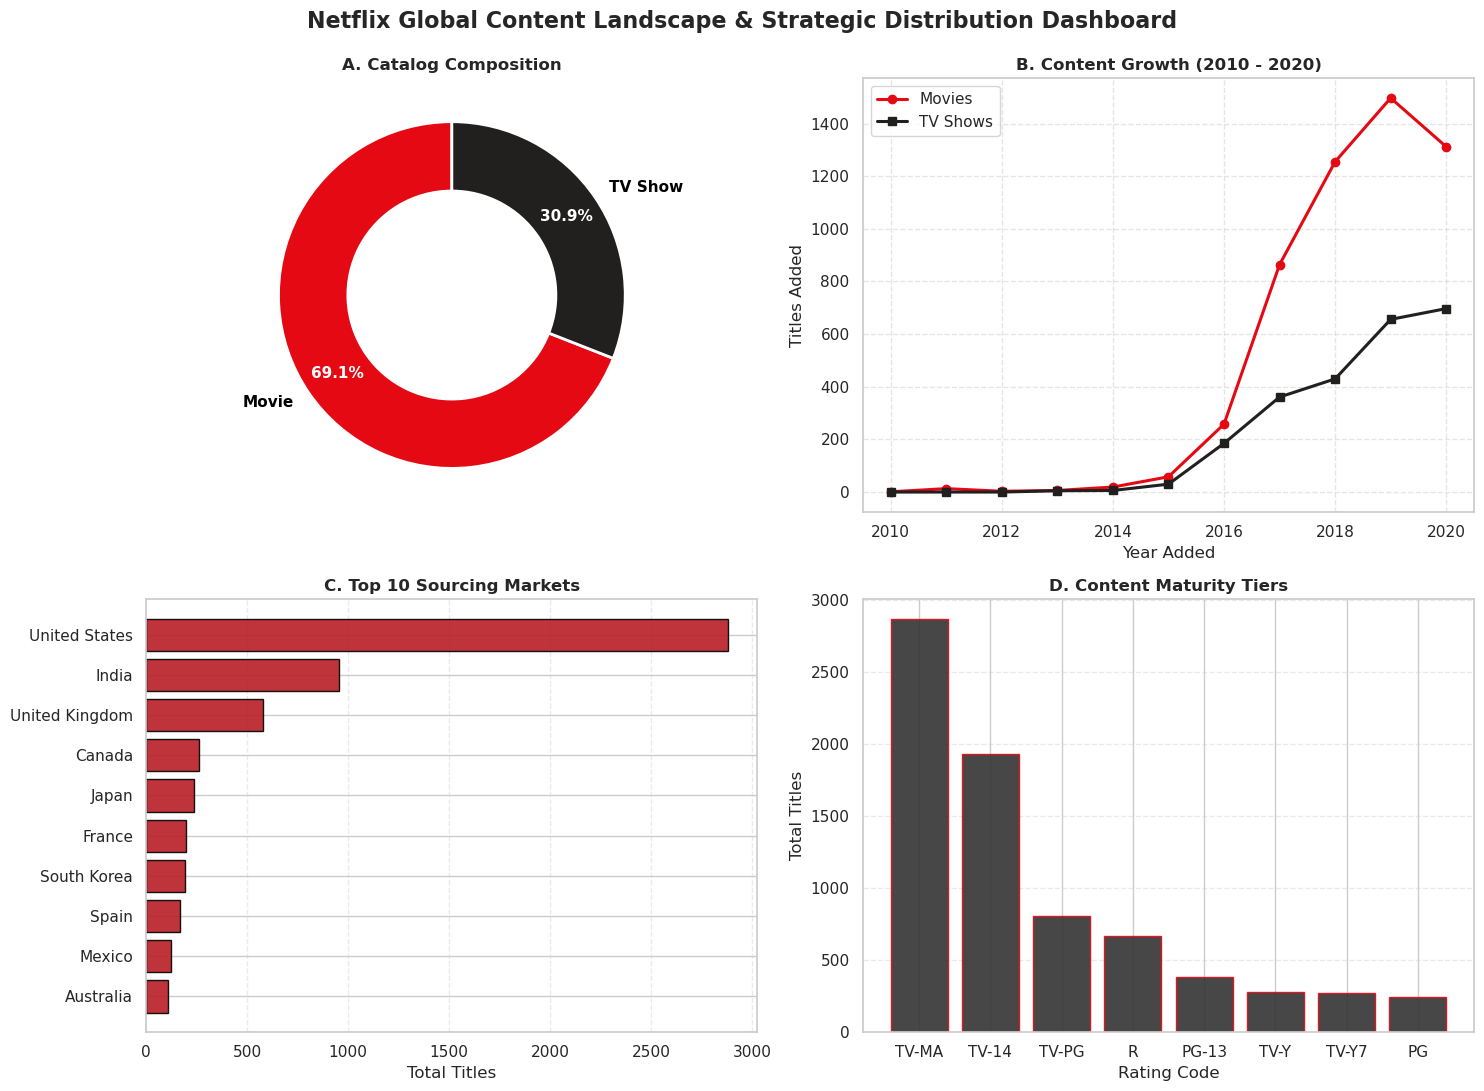

In [13]:
# 2x2 Subplot Dashboard Grid setup
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Subplot 1: Donut Chart (Type Composition)
colors = ["#E50914", "#221F1F"]
wedges, texts, autotexts = axes[0, 0].pie(
    type_counts, 
    labels=type_counts.index, 
    autopct="%1.1f%%", 
    pctdistance=0.8,
    startangle=90, 
    colors=colors,
    textprops=dict(fontsize=11, fontweight="bold", color="black"),
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2)
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
axes[0, 0].set_title("A. Catalog Composition", fontsize=12, fontweight="bold")

# Subplot 2: Time Series (Yearly Additions)
axes[0, 1].plot(yearly_trend.index, yearly_trend["Movie"], marker="o", linewidth=2.2, color="#E50914", label="Movies")
axes[0, 1].plot(yearly_trend.index, yearly_trend["TV Show"], marker="s", linewidth=2.2, color="#221F1F", label="TV Shows")
axes[0, 1].set_title("B. Content Growth (2010 - 2020)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Year Added")
axes[0, 1].set_ylabel("Titles Added")
axes[0, 1].grid(True, linestyle="--", alpha=0.5)
axes[0, 1].legend()

# Subplot 3: Top Sourcing Countries
axes[1, 0].barh(top_countries.index, top_countries.values, color="#B81D24", edgecolor="black", alpha=0.9)
axes[1, 0].set_title("C. Top 10 Sourcing Markets", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Total Titles")
axes[1, 0].grid(axis="x", linestyle="--", alpha=0.4)

# Subplot 4: Maturity Ratings
bars_r = axes[1, 1].bar(top_ratings.index, top_ratings.values, color="#333333", edgecolor="#E50914", alpha=0.9)
axes[1, 1].set_title("D. Content Maturity Tiers", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Rating Code")
axes[1, 1].set_ylabel("Total Titles")
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Netflix Global Content Landscape & Strategic Distribution Dashboard", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

> ## Strategic Business Takeaways
> 1. **Episodic Retention Play:** Bhale hi Movies ka share ~70% hai, 2018 ke baad se TV Shows mein continuous investment customer retention aur subscription churn reduce karne ke liye vital hai.
> 2. **Regional Expansion in APAC:** India, Japan, aur South Korea top sourcing markets mein shamil hain. Localized storytelling global subscriber acquisition ko boost kar rahi hai.
> 3. **Core Demographic:** Platform ka ~60%+ content Adult (`TV-MA`) aur Teen (`TV-14`) viewers par focused hai, jo primary paying subscriber base se align karta hai.